#Heart Disease Prediction

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Dataset Loading**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Heart_Disease_Prediction.csv')
display(df.head())
display(df.tail())

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence
269,67,1,4,160,286,0,2,108,1,1.5,2,3,3,Presence


**Basic Info**

In [ ]:
df.describe()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

(270, 14)

**Cleaning Missing Value's**

In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


**Exploratory Data Analysis (EDA)**

In [ ]:
sns.set(style="whitegrid")

**1- Age distribution**

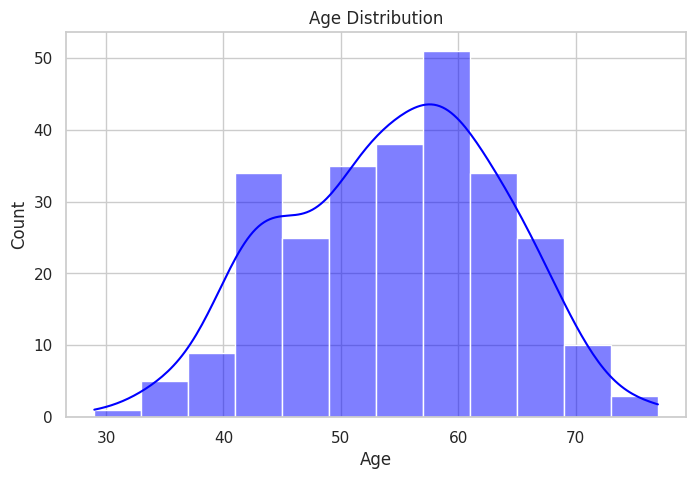

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], kde=True, color='blue')
plt.title('Age Distribution')
plt.show()

**2- Heart Disease vs Max HR**

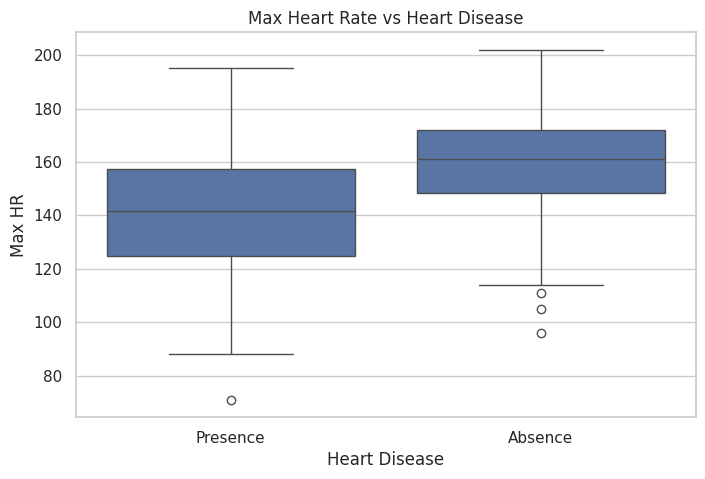

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Heart Disease', y='Max HR', data=df)
plt.title('Max Heart Rate vs Heart Disease')
plt.show()

**3- Correlation Heatmap**

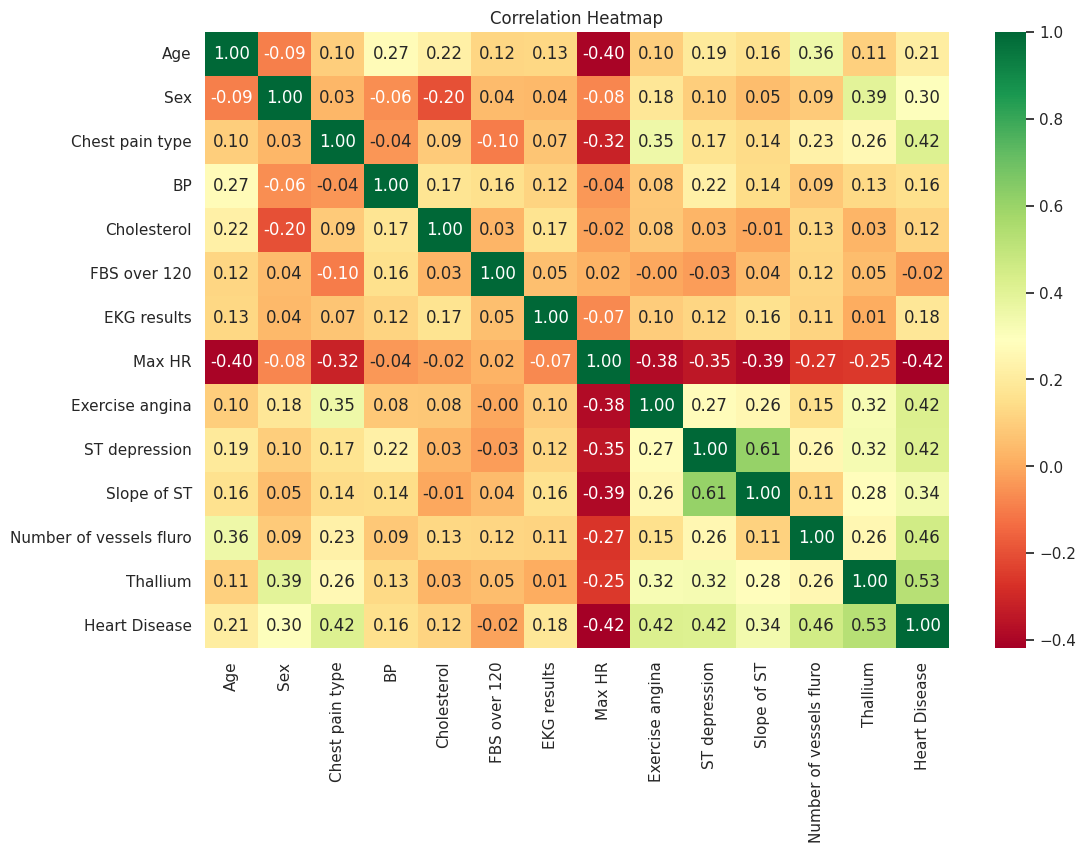

In [ ]:
plt.figure(figsize=(12, 8))
df_encoded = df.copy()
df_encoded['Heart Disease'] = LabelEncoder().fit_transform(df_encoded['Heart Disease'])
sns.heatmap(df_encoded.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

**Encoding target (Presence=1, Absence=0)**

In [ ]:
le = LabelEncoder()
df['Heart Disease'] = le.fit_transform(df['Heart Disease'])

**Splitting Features and Target**

In [ ]:
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

**Train-Test Split (80% Train, 20% Test)**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Feature Scaling (Important for Logistic Regression)**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Logistic Regression**

In [ ]:
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

In [ ]:
print("\n--- Logistic Regression Results ---")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds))


--- Logistic Regression Results ---
Accuracy: 0.9074
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54



**Random Forest**

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [ ]:
print("\n--- Random Forest Results ---")
print(f"Accuracy: {accuracy_score(y_test, rf_preds):.4f}")
print(classification_report(y_test, rf_preds))


--- Random Forest Results ---
Accuracy: 0.7963
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        33
           1       0.78      0.67      0.72        21

    accuracy                           0.80        54
   macro avg       0.79      0.77      0.78        54
weighted avg       0.79      0.80      0.79        54



**Feature Importance (Random Forest)**

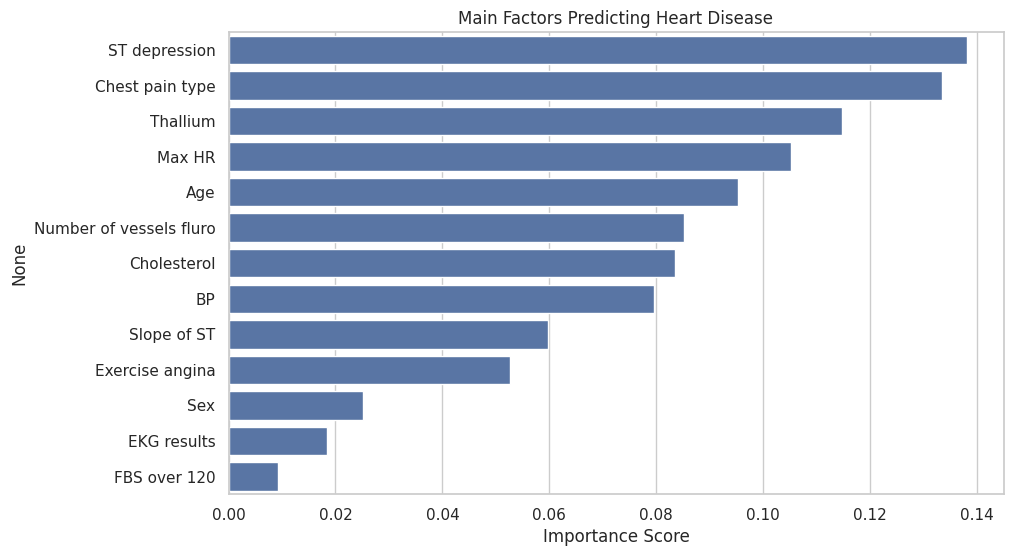

In [ ]:
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Main Factors Predicting Heart Disease')
plt.xlabel('Importance Score')
plt.show()